[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/catboost_boost_from_average.ipynb)

# CatBoost `boost_from_average`: it fixes where the model starts, not how far it goes

CatBoost starts `Logloss` and `MultiClass` from a raw score of zero: probability 0.5, or 1/K.
XGBoost 3.2 and LightGBM 4.6 start from the class prior, on binary and multiclass data alike.
`boost_from_average=True` moves CatBoost to the prior on `Logloss`; on `MultiClass` CatBoost
refuses it, and a baseline passed through `Pool` does the same job.

The start matters when a model barely leaves it, and a tuner that scores ranking lets it: PR AUC
and ROC AUC ignore probability scale, so a tiny `learning_rate * n_estimators` costs nothing
there. In a small-data benchmark tuned on PR AUC, CatBoost had the worst mean ECE of the gradient
boosters; the start turns out to explain part of that.

The benchmark's ten worst-calibrated datasets are refit here with the hyperparameters its tuning
chose, once from each start, and the same comparison over all 108 datasets is read from the
benchmark's results. Brier score and the confidence gap lead; ECE comes with a bootstrap
interval, because on 62 to 1212 rows it is noisy.

Under a minute of compute on a laptop CPU. A free Colab CPU is several times slower, and
installing the three pinned libraries adds a minute or two.

In [1]:
import importlib.metadata as md

PINS = {"catboost": "1.2.10", "xgboost": "3.2.0", "lightgbm": "4.6.0"}


def installed(package):
    try:
        return md.version(package)
    except md.PackageNotFoundError:
        return None


missing = [f"{p}=={v}" for p, v in PINS.items() if installed(p) != v]
if missing:
    %pip install -q {" ".join(missing)}
# Written with numpy 2.4.6, pandas 2.3.3, scikit-learn 1.7.2 and scipy 1.16.3.
print({p: installed(p) for p in ("numpy", "pandas", "scikit-learn", "scipy")})

{'numpy': '2.4.6', 'pandas': '2.3.3', 'scikit-learn': '1.7.2', 'scipy': '1.16.3'}


In [2]:
import io
import json
import urllib.request
import warnings

import lightgbm as lgb
import numpy as np
import pandas as pd
import xgboost as xgb
from catboost import CatBoostClassifier, CatBoostError, Pool
from scipy.io import arff
from scipy.stats import wilcoxon
from sklearn.metrics import average_precision_score, log_loss
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import label_binarize

# LightGBM names the columns of a NumPy array itself and then warns that they are missing.
warnings.filterwarnings("ignore", message="X does not have valid feature names")

BENCHMARK = "https://raw.githubusercontent.com/firefly1248/SmallDataBenchmarks/0267ce719ed916b682bb0c5a6fe17c0a25de6bd9/"
WORST = ["led7digit", "thyroid-newthyroid", "robot-failure-lp1", "leukemia-haslinger",
         "teaching-assistant-evaluation", "planning-relax", "appendicitis",
         "molecular-promotor-gene", "colon32", "hill-valley-without-noise"]
SEED, N_FOLDS, N_BOOT = 0, 4, 1000
BALANCED = 0.01  # KL(prior || uniform) below this, the prior is the uniform start
QUIET = dict(verbose=0, allow_writing_files=False)


def prior_start(y, loss):
    """Raw starting score at the class prior of y, where every class must appear:
    one log-odds for Logloss, one log prior per class for MultiClass."""
    log_prior = np.log(np.bincount(y) / len(y))
    return log_prior[1:] - log_prior[0] if loss == "Logloss" else log_prior


def pool(X, y=None, start=None):
    """A Pool that boosts from start, repeated for every row; None keeps CatBoost's zero start."""
    return Pool(X, y, baseline=None if start is None else np.tile(start, (len(X), 1)))


def confidence_gap(y, prob):
    """Mean top-class probability minus the share of rows whose top class is right. Negative: underconfident."""
    return prob.max(axis=1).mean() - (prob.argmax(axis=1) == y).mean()


def brier(y, prob):
    """Multiclass Brier score, summed over classes: 0 to 2."""
    return np.mean(np.sum((prob - np.eye(prob.shape[1])[y]) ** 2, axis=1))


def ece(y, prob, n_bins=15):
    """Top-label ECE, equal-width bins over the observed confidence range, as in the benchmark."""
    confidence, correct = prob.max(axis=1), (prob.argmax(axis=1) == y).astype(float)
    binned = np.digitize(confidence, np.linspace(confidence.min(), confidence.max(), n_bins + 1)[1:-1])
    return np.abs(np.bincount(binned, confidence, n_bins) - np.bincount(binned, correct, n_bins)).sum() / len(y)


def pr_auc(y, prob):
    """Weighted average precision, the benchmark's ranking metric."""
    if prob.shape[1] == 2:
        return average_precision_score(y, prob[:, 1])
    return average_precision_score(label_binarize(y, classes=np.arange(prob.shape[1])), prob, average="weighted")

## Where each booster starts

Five trees at a learning rate of 0.001 barely move any model, so what they predict is where they
started. The data is noise with an imbalanced label, binary and four-class.

In [3]:
rng = np.random.default_rng(SEED)
X_syn = rng.normal(size=(2000, 5))
targets = {"binary": (rng.random(2000) < 0.15).astype(int),
           "4 classes": rng.choice(4, 2000, p=[0.6, 0.25, 0.1, 0.05])}
barely = dict(learning_rate=1e-3, n_estimators=5, random_state=SEED)
rows = {}
for task, y_syn in targets.items():
    rows[f"{task}: class prior"] = np.bincount(y_syn) / len(y_syn)
    rows[f"{task}: CatBoost"] = CatBoostClassifier(**barely, **QUIET).fit(X_syn, y_syn).predict_proba(X_syn).mean(axis=0)
    rows[f"{task}: XGBoost"] = xgb.XGBClassifier(**barely).fit(X_syn, y_syn).predict_proba(X_syn).mean(axis=0)
    rows[f"{task}: LightGBM"] = lgb.LGBMClassifier(**barely, verbose=-1).fit(X_syn, y_syn).predict_proba(X_syn).mean(axis=0)
print(pd.DataFrame.from_dict(rows, orient="index").round(3).fillna("").to_string())

                            0      1      2      3
binary: class prior     0.854  0.146              
binary: CatBoost        0.502  0.498              
binary: XGBoost         0.854  0.146              
binary: LightGBM        0.854  0.146              
4 classes: class prior  0.580  0.272  0.097  0.052
4 classes: CatBoost     0.251  0.250  0.249  0.249
4 classes: XGBoost      0.580  0.271  0.097  0.051
4 classes: LightGBM     0.580  0.272  0.097  0.052


XGBoost says where its start comes from: the intercept it estimated, one per class on
multiclass data since 3.1, equal to the log prior up to a constant. LightGBM folds the log prior
into its first trees; with `boost_from_average=False` it starts from uniform like CatBoost. Its
docs list the flag only for `regression`, `binary`, `multiclassova` and `cross-entropy`, but 4.6
applies it to softmax `multiclass` too, as the next cell shows.

In [4]:
y4 = targets["4 classes"]
booster = xgb.XGBClassifier(**barely).fit(X_syn, y4).get_booster()
intercept = json.loads(booster.save_config())["learner"]["learner_model_param"]["base_score"]
# Softmax ignores a constant added to every class, so compare the two centred.
centred = lambda v: np.round(np.asarray(v) - np.mean(v), 3)
print("XGBoost intercept, centred  ", centred(json.loads(intercept)))
print("log class prior, centred    ", centred(np.log(np.bincount(y4) / len(y4))))
no_average = lgb.LGBMClassifier(**barely, verbose=-1, boost_from_average=False).fit(X_syn, y4)
print("LightGBM without the prior  ", no_average.predict_proba(X_syn).mean(axis=0).round(3))

XGBoost intercept, centred   [ 1.242  0.483 -0.546 -1.179]
log class prior, centred     [ 1.242  0.483 -0.546 -1.179]


LightGBM without the prior   [0.252 0.25  0.249 0.249]


## `boost_from_average` exists for `Logloss` only

On binary data the flag and a baseline at the log-odds of the prior give the same model. On
`MultiClass` the flag raises, and the baseline, one log prior per class, is the only route.

In [5]:
y2 = targets["binary"]
flag = CatBoostClassifier(**barely, **QUIET, boost_from_average=True).fit(X_syn, y2).predict_proba(X_syn)
start = prior_start(y2, "Logloss")
model = CatBoostClassifier(**barely, **QUIET).fit(pool(X_syn, y2, start))
via_baseline = model.predict_proba(pool(X_syn, start=start))
print(f"binary: flag vs baseline, max |difference| {np.abs(flag - via_baseline).max():.1e}")

try:
    CatBoostClassifier(**barely, **QUIET, loss_function="MultiClass", boost_from_average=True).fit(X_syn, y4)
except CatBoostError as error:
    print("MultiClass with the flag:", str(error).split(": ", 1)[-1])

start4 = prior_start(y4, "MultiClass")
model4 = CatBoostClassifier(**barely, **QUIET, loss_function="MultiClass").fit(pool(X_syn, y4, start4))
print("MultiClass with a baseline, mean probability", model4.predict_proba(pool(X_syn, start=start4)).mean(axis=0).round(3))

binary: flag vs baseline, max |difference| 8.6e-09
MultiClass with the flag: You can use boost_from_average only for these loss functions now: RMSE, Logloss, CrossEntropy, Quantile, MultiQuantile, MAE, MAPE, MultiRMSE, MultiRMSEWithMissingValues or RMSPE.
MultiClass with a baseline, mean probability [0.58  0.271 0.097 0.051]


The model does not store the baseline. Prediction has to pass it again, or every probability
shifts by the start that was left out.

In [6]:
print(f"class prior                  {y2.mean():.3f}")
print(f"predicted with the baseline    {via_baseline[:, 1].mean():.3f}")
print(f"predicted without it           {model.predict_proba(X_syn)[:, 1].mean():.3f}")

class prior                  0.146
predicted with the baseline    0.146
predicted without it           0.500


## Ten datasets, same hyperparameters, two starts

Each outer fold's final model is refit with the hyperparameters the benchmark's tuning chose for
it, once from zero, as the benchmark fitted it, and once from the prior. Nothing else changes, so
the difference is the start.

`KL` is the divergence of the class prior from uniform: 0 on balanced data, where the two starts
coincide. Below 0.01 a dataset counts as nearly balanced here, which admits up to about 56/44 on
binary data. `gap` is the mean top-class probability minus the share of rows whose top class is
right; negative means underconfident. `lr x trees` is `learning_rate * n_estimators`, the median
over the four folds.

In [7]:
params = pd.read_csv(BENCHMARK + "results/best_params.csv")
params = params[params.model == "catboost_uniform_start"]
INTEGER = {"depth", "n_estimators", "min_data_in_leaf"}


def load(name):
    with urllib.request.urlopen(f"{BENCHMARK}datasets/{name}.arff") as response:
        df = pd.DataFrame(arff.loadarff(io.StringIO(response.read().decode()))[0])
    target = df.pop("Class").str.decode("utf-8")
    return df.astype(float), target.map({c: i for i, c in enumerate(sorted(target.unique()))}).to_numpy()


def fold_params(name, fold):
    p = params[(params.dataset == name) & (params.fold == fold)]
    return {k: int(float(v)) if k in INTEGER else float(v) for k, v in zip(p.param, p.value)}


def refit(X, y, name):
    """Out-of-fold probabilities from both starts, and the median learning_rate * n_estimators."""
    loss = "Logloss" if len(np.unique(y)) == 2 else "MultiClass"
    probs, labels, budget = {"uniform": [], "prior": []}, [], []
    for fold, (train, test) in enumerate(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(X, y)):
        p = fold_params(name, fold)
        budget.append(p["learning_rate"] * p["n_estimators"])
        for arm in probs:
            start = prior_start(y[train], loss) if arm == "prior" else None
            model = CatBoostClassifier(loss_function=loss, bootstrap_type="Bernoulli", random_state=SEED,
                                       **QUIET, **p)
            model.fit(pool(X.iloc[train], y[train], start))
            probs[arm].append(model.predict_proba(pool(X.iloc[test], start=start)))
        labels.append(y[test])
    return probs, labels, np.median(budget)


def ece_interval(y, prob, rng):
    """90% bootstrap interval over rows, for one arm; it says nothing about the paired difference."""
    draws = []
    for _ in range(N_BOOT):
        picked = rng.integers(0, len(y), len(y))
        draws.append(ece(y[picked], prob[picked]))
    return np.percentile(draws, [5, 95])


rng = np.random.default_rng(SEED)
rows = []
for name in WORST:
    X, y = load(name)
    probs, labels, budget = refit(X, y, name)
    y_all, share = np.concatenate(labels), np.bincount(y) / len(y)
    row = {"dataset": name, "rows": len(y), "classes": len(share),
           "KL": np.sum(share * np.log(share * len(share))), "lr x trees": budget}
    for arm, folds in probs.items():
        prob = np.vstack(folds)
        lo, hi = ece_interval(y_all, prob, rng)
        row |= {f"Brier {arm}": brier(y_all, prob), f"gap {arm}": confidence_gap(y_all, prob),
                f"ECE {arm}": ece(y_all, prob), f"ECE {arm} lo": lo, f"ECE {arm} hi": hi,
                f"PR AUC {arm}": np.mean([pr_auc(l, q) for l, q in zip(labels, folds)])}
    rows.append(row)
worst = pd.DataFrame(rows).set_index("dataset").sort_values("KL", ascending=False)
print(worst[["rows", "classes", "KL", "lr x trees", "Brier uniform", "Brier prior",
             "gap uniform", "gap prior"]].round(3).to_string())
print()
print(worst[["ECE uniform", "ECE prior", "PR AUC uniform", "PR AUC prior"]].round(3).to_string())

# The same refit over all 108 datasets, from the benchmark's run.
effect = pd.read_csv(BENCHMARK + "results/catboost_start_effect.csv").rename(columns={"shrink": "lr x trees"})
effect["group"] = np.where(effect.kl_prior_uniform < BALANCED, "balanced", "imbalanced")
theirs = effect.set_index("dataset").loc[worst.index]
print(f"\nuniform arm vs the benchmark's run, max |Brier difference|: "
      f"{np.abs(worst['Brier uniform'] - theirs.brier_uniform).max():.1e}")

                               rows  classes     KL  lr x trees  Brier uniform  Brier prior  gap uniform  gap prior
dataset                                                                                                            
thyroid-newthyroid              215        3  0.277       1.402          0.290        0.235       -0.274     -0.030
appendicitis                    106        2  0.195       0.685          0.345        0.271       -0.233      0.005
planning-relax                  182        2  0.095      52.170          0.544        0.522        0.202      0.203
robot-failure-lp1                88        4  0.049       2.721          0.368        0.347       -0.265     -0.209
colon32                          62        2  0.043       5.146          0.355        0.321       -0.108      0.028
led7digit                       500       10  0.007       0.740          0.664        0.664       -0.447     -0.431
teaching-assistant-evaluation   151        3  0.000      40.782         


uniform arm vs the benchmark's run, max |Brier difference|: 4.7e-07


Read the changes against how far a refit moves when the start barely changes. Any change in the
start changes the gradients, and with them the trees: over the 30 nearly balanced datasets below,
Brier improves by at most 0.005 and worsens by up to 0.026. Thyroid (Brier -0.055), appendicitis
(-0.074) and colon32 (-0.034) improve by far more than that, all on imbalanced data, and on
thyroid and appendicitis the underconfidence all but disappears. `robot-failure-lp1` and
`planning-relax` improve by about 0.02: more than any nearly balanced dataset improves, less than
the most one worsens. `led7digit`, nearly
balanced, stays as underconfident as it was. The three datasets with a large `lr x trees` are
overconfident, and the start has no consistent effect on them.

`colon32` shows why ECE does not lead: on 62 rows its ECE worsens while Brier and the gap both
improve. PR AUC moves by at most 0.023, in both directions: the trees change a little, and on
multiclass data a per-class offset also re-ranks rows within each class.

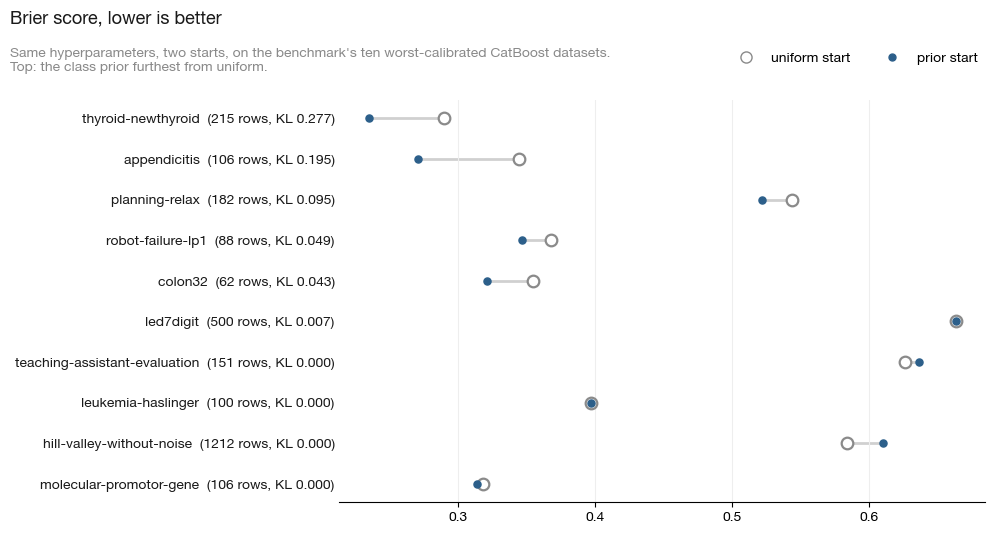

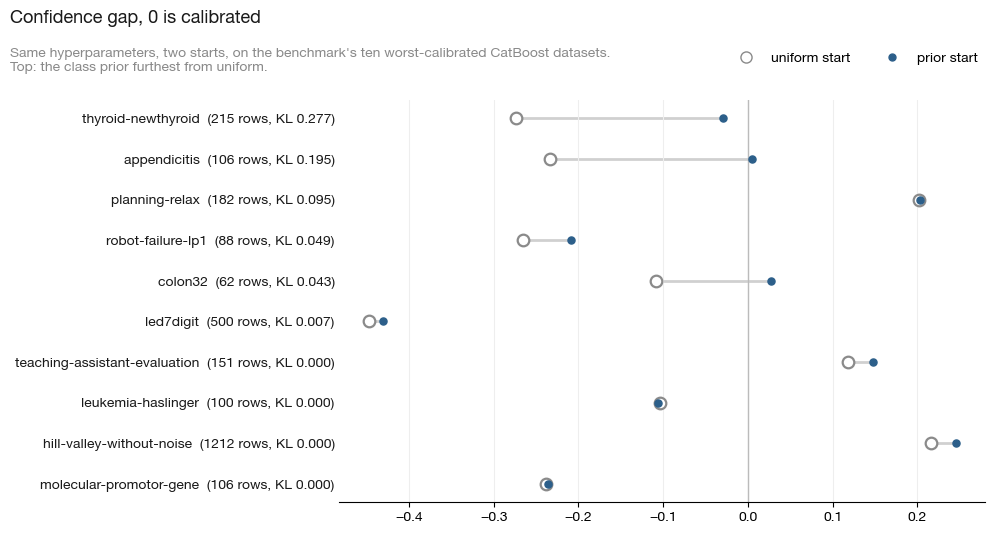

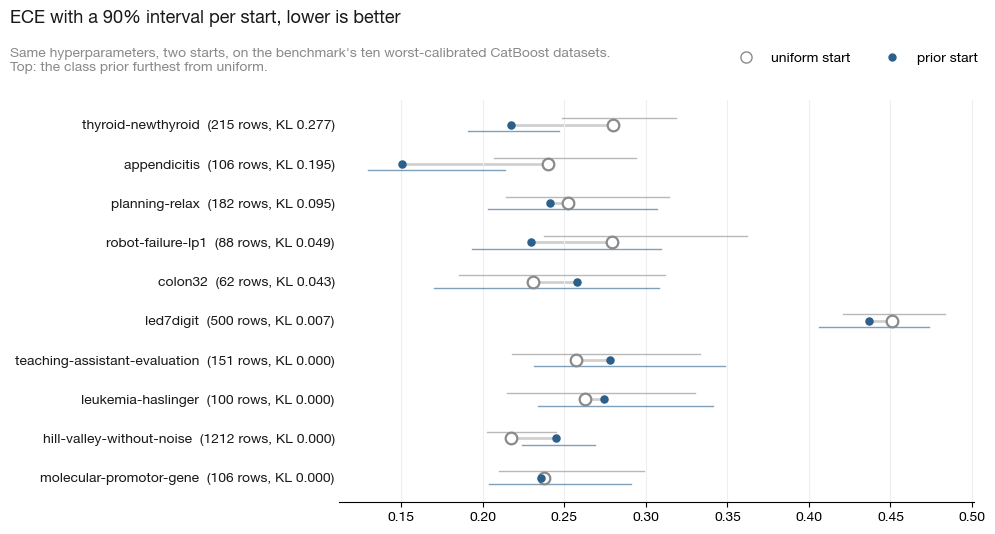

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE, GREY, INK = "#2C5F8A", "#8a8a8a", "#1a1a1a"
PANELS = [("Brier", "Brier score, lower is better"), ("gap", "Confidence gap, 0 is calibrated"),
          ("ECE", "ECE with a 90% interval per start, lower is better")]
SUBTITLE = ("Same hyperparameters, two starts, on the benchmark's ten worst-calibrated CatBoost datasets.\n"
            "Top: the class prior furthest from uniform.")
handles = [plt.Line2D([], [], marker="o", ls="", markersize=8, markerfacecolor="white", markeredgecolor=GREY,
                      label="uniform start"),
           plt.Line2D([], [], marker="o", ls="", markersize=5, color=BLUE, label="prior start")]

order = worst.index[::-1]
for metric, title in PANELS:
    fig, ax = plt.subplots(figsize=(10, 5.4))
    if metric == "gap":
        ax.axvline(0, color="#bbbbbb", lw=1)
    for i, name in enumerate(order):
        r = worst.loc[name]
        ax.plot([r[f"{metric} uniform"], r[f"{metric} prior"]], [i, i], color="#d0d0d0", lw=2, zorder=1)
        if metric == "ECE":
            for arm, color, dy in (("uniform", GREY, 0.16), ("prior", BLUE, -0.16)):
                ax.plot([r[f"ECE {arm} lo"], r[f"ECE {arm} hi"]], [i + dy, i + dy], color=color, lw=1, alpha=0.6)
        # The prior marker is drawn smaller, so an unchanged dataset still shows both.
        ax.scatter(r[f"{metric} uniform"], i, s=70, color="white", edgecolor=GREY, lw=1.6, zorder=2)
        ax.scatter(r[f"{metric} prior"], i, s=26, color=BLUE, zorder=3)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([f"{n}  ({worst.loc[n, 'rows']} rows, KL {worst.loc[n, 'KL']:.3f})" for n in order],
                       color=INK)
    ax.grid(axis="x", color="#eeeeee")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.99, 0.925), ncol=2, frameon=False)
    fig.suptitle(title, x=0.01, y=0.98, ha="left", color=INK, fontsize=13)
    fig.text(0.01, 0.91, SUBTITLE, va="top", color=GREY, fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 0.9))
    fig.savefig(f"catboost_boost_from_average_{metric.lower()}.png", dpi=150, facecolor="white")
    plt.show()

## All 108 datasets

The same refit over every dataset in the benchmark's calibration figure.

In [9]:
summary = {}
for group, g in [("all", effect), *effect.groupby("group")]:
    brier_change, prauc_change = g.brier_prior - g.brier_uniform, g.prauc_prior - g.prauc_uniform
    summary[group] = {
        "datasets": len(g),
        "Brier better": f"{(brier_change < 0).sum()} of {len(g)}",
        "mean Brier change": brier_change.mean(),
        "largest |Brier change|": brier_change.abs().max(),
        "Wilcoxon p, Brier": wilcoxon(brier_change).pvalue,
        "mean |gap| uniform": g.gap_uniform.abs().mean(),
        "mean |gap| prior": g.gap_prior.abs().mean(),
        "mean ECE uniform": g.ece_uniform.mean(),
        "mean ECE prior": g.ece_prior.mean(),
        "mean PR AUC change": prauc_change.mean(),
        "Wilcoxon p, PR AUC": wilcoxon(prauc_change).pvalue,
    }
print(pd.DataFrame(summary).to_string(float_format=lambda v: f"{v:.4f}"))

                              all  balanced imbalanced
datasets                      108        30         78
Brier better            64 of 108  13 of 30   51 of 78
mean Brier change         -0.0058    0.0012    -0.0084
largest |Brier change|     0.0868    0.0260     0.0868
Wilcoxon p, Brier          0.0030    0.7222     0.0005
mean |gap| uniform         0.0590    0.0816     0.0503
mean |gap| prior           0.0431    0.0809     0.0286
mean ECE uniform           0.0848    0.1028     0.0778
mean ECE prior             0.0720    0.1022     0.0604
mean PR AUC change         0.0004    0.0002     0.0004
Wilcoxon p, PR AUC         0.5308    0.5296     0.6902


The start improves Brier on imbalanced data and does nothing on average on balanced data,
where single datasets still move, by up to 0.026 for the worse and 0.005 for the better. Ranking
does not move.

Where the tuning gave CatBoost a small budget (`lr x trees` below 5), the start removes the gap on
imbalanced data and leaves it on balanced data. Where all three boosters got a small budget, the
prior start brings CatBoost level with the other two.

In [10]:
small = effect[effect["lr x trees"] < 5]
print("CatBoost with a small budget, mean confidence gap")
print(small.groupby("group").agg(datasets=("dataset", "size"), uniform=("gap_uniform", "mean"),
                                 prior=("gap_prior", "mean")).round(3).to_string())

# The other boosters' gaps and budgets, from the benchmark's own runs.
calib = pd.read_csv(BENCHMARK + "results/catboost_calibration.csv")
budget = calib.pivot(index="dataset", columns="model", values="shrink")
gap = calib.pivot(index="dataset", columns="model", values="confidence_gap")
all_small = budget.index[(budget[["catboost", "xgboost", "lgbm"]] < 5).all(axis=1)]
start = effect.set_index("dataset").loc[all_small]
print(f"\nThe {len(all_small)} datasets where all three got a small budget, mean confidence gap")
print(pd.Series({"CatBoost, uniform start": start.gap_uniform.mean(),
                 "CatBoost, prior start": start.gap_prior.mean(),
                 "XGBoost": gap.loc[all_small, "xgboost"].mean(),
                 "LightGBM": gap.loc[all_small, "lgbm"].mean()}).round(3).to_string())

CatBoost with a small budget, mean confidence gap
            datasets  uniform  prior
group                               
balanced           8   -0.172 -0.168
imbalanced        21   -0.099 -0.006



The 14 datasets where all three got a small budget, mean confidence gap
CatBoost, uniform start   -0.096
CatBoost, prior start     -0.025
XGBoost                   -0.038
LightGBM                  -0.034


## Why the rest stays underconfident

On the balanced small-budget datasets the start cannot help, and the benchmark's own runs show
what does: on those same datasets the tuning gave XGBoost and LightGBM larger budgets, and they
ended up far less underconfident.

In [11]:
stuck = small[small.group == "balanced"].dataset
print(pd.DataFrame({"median lr x trees": budget.loc[stuck, ["catboost", "xgboost", "lgbm"]].median(),
                    "mean gap": gap.loc[stuck, ["catboost", "xgboost", "lgbm"]].mean()}).round(3).to_string())

          median lr x trees  mean gap
model                                
catboost              1.374    -0.172
xgboost               6.216    -0.086
lgbm                  4.315    -0.034


The libraries themselves move at comparable speed. With learning rate, trees, depth and L2
matched, and everything else at each library's defaults (CatBoost grows symmetric trees, XGBoost
depth-wise and LightGBM leaf-wise ones), test log loss on two larger datasets:

In [12]:
def paced(X, y, checkpoints=(10, 30, 100, 300)):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
    loss = "Logloss" if len(np.unique(y)) == 2 else "MultiClass"
    shared = dict(learning_rate=0.01, n_estimators=max(checkpoints), random_state=SEED)
    ll = lambda p: log_loss(y_te, p, labels=np.unique(y))
    curves = {}
    for arm in ("uniform", "prior"):
        start = prior_start(y_tr, loss) if arm == "prior" else None
        cat = CatBoostClassifier(**shared, **QUIET, loss_function=loss, depth=6, l2_leaf_reg=1.0)
        cat.fit(pool(X_tr, y_tr, start))
        test = pool(X_te, start=start)
        curves[f"CatBoost, {arm} start"] = [ll(cat.predict_proba(test, ntree_end=t)) for t in checkpoints]
    xg = xgb.XGBClassifier(**shared, max_depth=6, reg_lambda=1.0, min_child_weight=0).fit(X_tr, y_tr)
    lg = lgb.LGBMClassifier(**shared, max_depth=6, num_leaves=64, reg_lambda=1.0,
                            min_child_samples=1, verbose=-1).fit(X_tr, y_tr)
    curves["XGBoost"] = [ll(xg.predict_proba(X_te, iteration_range=(0, t))) for t in checkpoints]
    curves["LightGBM"] = [ll(lg.predict_proba(X_te, num_iteration=t)) for t in checkpoints]
    return pd.DataFrame(curves, index=pd.Index(checkpoints, name="trees")).T


for name in ("phoneme", "page-blocks"):
    X, y = load(name)
    print(f"\n{name}: {len(y)} rows, {len(np.unique(y))} classes, prior {np.round(np.bincount(y) / len(y), 2)}")
    print(paced(X, y).round(3).to_string())


phoneme: 5404 rows, 2 classes, prior [0.71 0.29]


trees                      10     30     100    300
CatBoost, uniform start  0.615  0.516  0.386  0.321
CatBoost, prior start    0.554  0.486  0.386  0.321
XGBoost                  0.563  0.500  0.390  0.296
LightGBM                 0.564  0.502  0.392  0.300



page-blocks: 5473 rows, 5 classes, prior [0.9  0.06 0.01 0.02 0.02]


trees                      10     30     100    300
CatBoost, uniform start  1.322  0.965  0.444  0.129
CatBoost, prior start    0.354  0.269  0.158  0.088
XGBoost                  0.353  0.271  0.161  0.100
LightGBM                 0.326  0.229  0.129  0.090


From the prior start CatBoost keeps pace. On phoneme it leads the other two up to 100 trees and
trails at 300 (0.321 against 0.296 and 0.300); on page-blocks it tracks XGBoost, behind LightGBM,
up to 100 trees and is ahead of both at 300. From the uniform start it first has to work off the
offset: on phoneme it has caught up by 100 trees, and on page-blocks, with a 90% majority class,
it is still behind at 300 (0.129 against 0.088). These curves stop at a `learning_rate *
n_estimators` of 3, the range the tuning chose for CatBoost on many small datasets.

## Takeaway

Set a prior start on CatBoost: `boost_from_average=True` on binary data, a baseline in `Pool` on
multiclass data, passed again at prediction. It removes an offset that XGBoost and LightGBM do not
have, and ranking does not move (Wilcoxon p = 0.53 on PR AUC over 108 datasets). On nearly
balanced data Brier does not change on average, but a single refit can still move it either way,
by up to 0.026 for the worse.

It fixes where the model starts, not how far it goes: a model tuned on a ranking metric can still
be given too small a budget to leave its start. That part needs a tuning metric that reads probabilities, such as log loss, or a
calibration step.